### Spectral clustering on the autonomous Duffing system

In [ ]:
from pathlib import Path

import numpy as np

from spectral_clustering import (
    SpectralClusteringConfig,
    calculate_eigenvalues,
    calculate_num_clusters_and_max_eigengap,
    calculate_spectral_indicators,
    compute_weight_matrix,
    find_clusters,
    find_local_maxima,
    generate_initial_conditions,
    ode_autonomous_duffing,
    plot_clusters,
    plot_clusters_local_maxs,
    plot_eigengaps_vs_index,
    plot_eigengaps_vs_sparsity,
    plot_eigenvalues_vs_index,
    simulate_trajectories,
    sparsify,
)

np.set_printoptions(precision=3, suppress=True)
%load_ext autoreload
%autoreload 2

In [ ]:
params = SpectralClusteringConfig(
    output_dir=Path("../output").resolve(),
    num_dimensions=2,
    t_span=(0, 4 * np.pi),
    t_steps=300,
    x_min=-1.6,
    x_max=1.6,
    y_min=-1.0,
    y_max=1.0,
    grid_spacing=0.04,
    max_clusters=50,
    num_radii=50,
)

In [3]:
initial_conditions = generate_initial_conditions(params)
trajectories = simulate_trajectories(ode_autonomous_duffing, initial_conditions, params)
print("(Num trajectories, t_steps, num_dimension) =", trajectories.shape)

(Num trajectories, t_steps, num_dimension) = (4131, 300, 2)


In [4]:
weight_matrix = compute_weight_matrix(trajectories)

In [5]:
max_weight = np.max(weight_matrix)
print(f"Maximum weight in weight matrix: {max_weight:.3f}")
default_diagonal_constant = max_weight * 1e7

Maximum weight in weight matrix: 107.033


Sparsification of 90% achieved using 1.313 as the sparsification radius.
similarity_matrix =
 [[1.070e+09 1.851e+01 8.962e+00 ... 0.000e+00 0.000e+00 0.000e+00]
 [1.851e+01 1.070e+09 1.729e+01 ... 0.000e+00 0.000e+00 0.000e+00]
 [8.962e+00 1.729e+01 1.070e+09 ... 0.000e+00 0.000e+00 0.000e+00]
 ...
 [0.000e+00 0.000e+00 0.000e+00 ... 1.070e+09 1.729e+01 8.962e+00]
 [0.000e+00 0.000e+00 0.000e+00 ... 1.729e+01 1.070e+09 1.851e+01]
 [0.000e+00 0.000e+00 0.000e+00 ... 8.962e+00 1.851e+01 1.070e+09]]
eigvectors.shape = (4131, 50)
50 eigvals = [-7.3e-19 8.8e-09 1.2e-08 1.2e-08 1.5e-08 2.3e-08 2.6e-08 4.6e-08 4.9e-08
 5.2e-08 5.3e-08 6.2e-08 6.4e-08 6.5e-08 7.3e-08 7.3e-08 8.2e-08 8.2e-08
 8.7e-08 9.3e-08 9.4e-08 9.4e-08 9.5e-08 9.5e-08 9.9e-08 9.9e-08 1.0e-07
 1.0e-07 1.0e-07 1.1e-07 1.1e-07 1.1e-07 1.1e-07 1.2e-07 1.2e-07 1.2e-07
 1.2e-07 1.2e-07 1.2e-07 1.2e-07 1.3e-07 1.3e-07 1.3e-07 1.3e-07 1.4e-07
 1.4e-07 1.4e-07 1.4e-07 1.4e-07 1.4e-07]


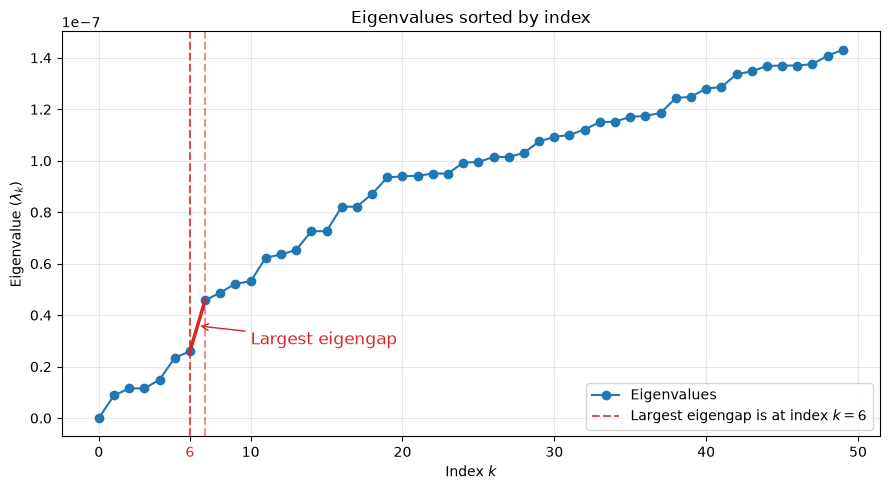

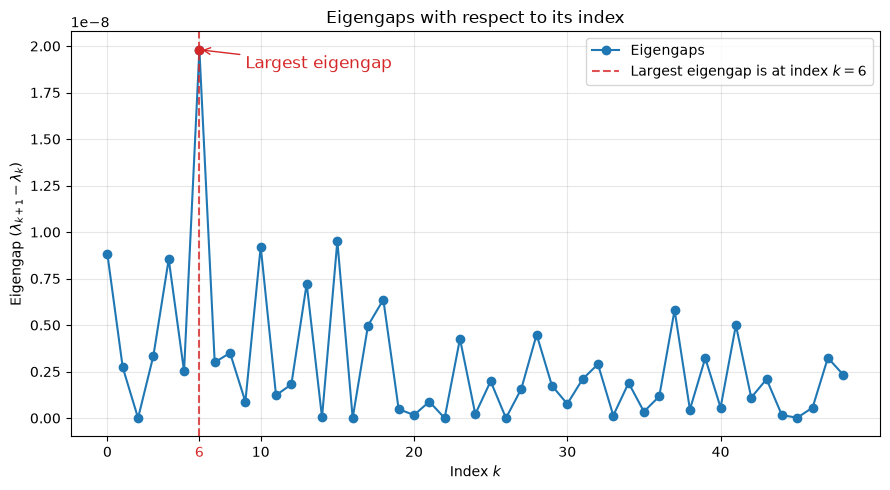

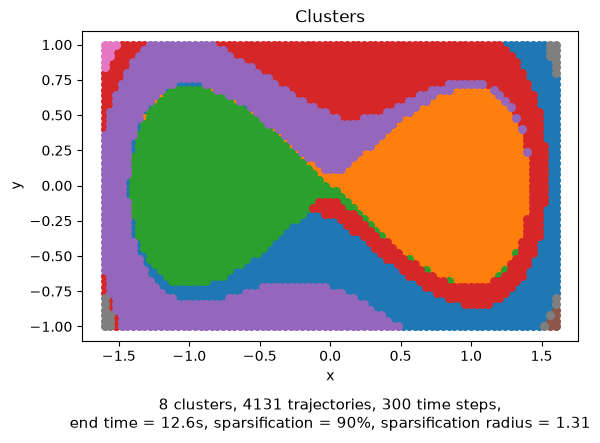

In [ ]:
# Option A: esparsify at 90%
similarity_matrix, sparsification_radius, sparsification_percent = sparsify(
    weight_matrix, sparsification_percent=90
)
print(
    f"Sparsification of {sparsification_percent * 100:.0f}% achieved "
    f"using {sparsification_radius:.3f} as the sparsification radius."
)
np.fill_diagonal(similarity_matrix, default_diagonal_constant)
print("similarity_matrix =\n", similarity_matrix)
eigvals, eigvectors = calculate_eigenvalues(similarity_matrix, params.max_clusters)
print("eigvectors.shape =", eigvectors.shape)
print(
    len(eigvals),
    "eigvals =",
    np.array2string(eigvals, formatter={"float_kind": lambda x: f"{x:.1e}"}),
)
ax_eig_vals = plot_eigenvalues_vs_index(
    eigvals, output_dir=params.output_dir, subfolder="autonomous"
)

In [ ]:
ax_eig_gaps = plot_eigengaps_vs_index(
    eigvals, output_dir=params.output_dir, subfolder="autonomous"
)

In [ ]:
num_clusters, diff_max = calculate_num_clusters_and_max_eigengap(eigvals)
labels = find_clusters(num_clusters, eigvectors)
ax_clusters = plot_clusters(
    initial_conditions,
    labels,
    num_clusters,
    sparsification_radius,
    sparsification_percent,
    params,
    output_dir=params.output_dir,
    subfolder="autonomous",
)

In [7]:
# Option B: adaptive method
# Choose the sparsification radii that maximize the largest eigengap
result = calculate_spectral_indicators(weight_matrix, default_diagonal_constant, params)

local_maxs_indices = [3, 37, 41]
radii[local_maxs_indices] = [0.395 1.433 1.555]
Local maximum #1
Sparsification radius: 0.395, Sparsification percent: 0.65%, Clusters: 2, Max eigengap: 2.08107e-06


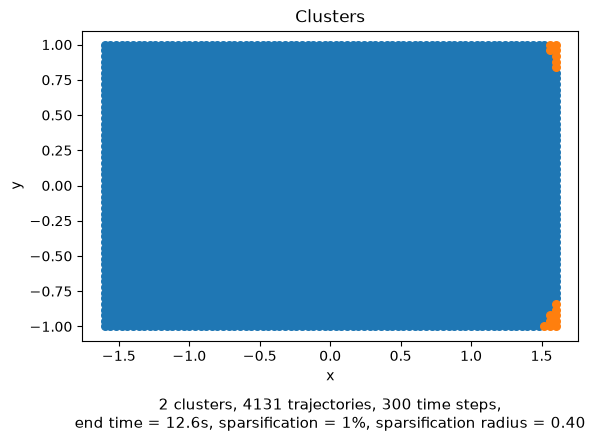

Local maximum #2
Sparsification radius: 1.433, Sparsification percent: 91.66%, Clusters: 8, Max eigengap: 1.78715e-08


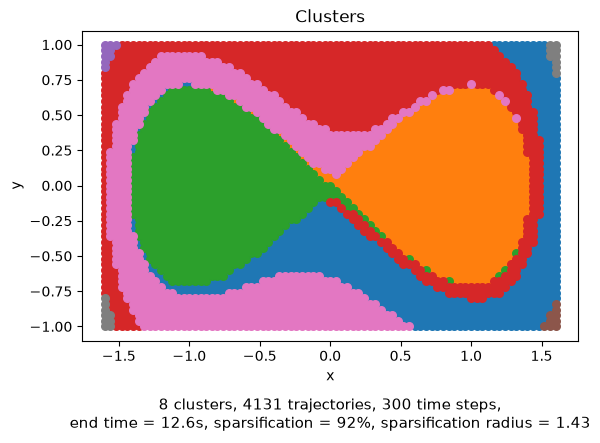

Local maximum #3
Sparsification radius: 1.555, Sparsification percent: 93.13%, Clusters: 8, Max eigengap: 1.46908e-08


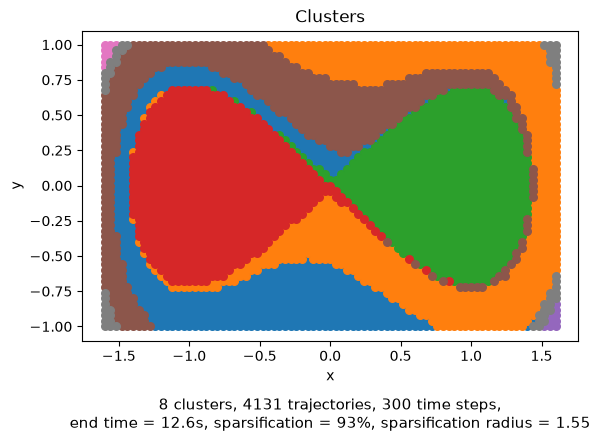

In [ ]:
local_maxs_indices = find_local_maxima(result.normalized_eigengaps)
print("local_maxs_indices =", local_maxs_indices)
print("radii[local_maxs_indices] =", result.sparsification_radii[local_maxs_indices])
ax_local_maxs = plot_clusters_local_maxs(
    local_maxs_indices,
    result,
    initial_conditions,
    params,
    output_dir=params.output_dir,
    subfolder="autonomous_local_maxs",
)

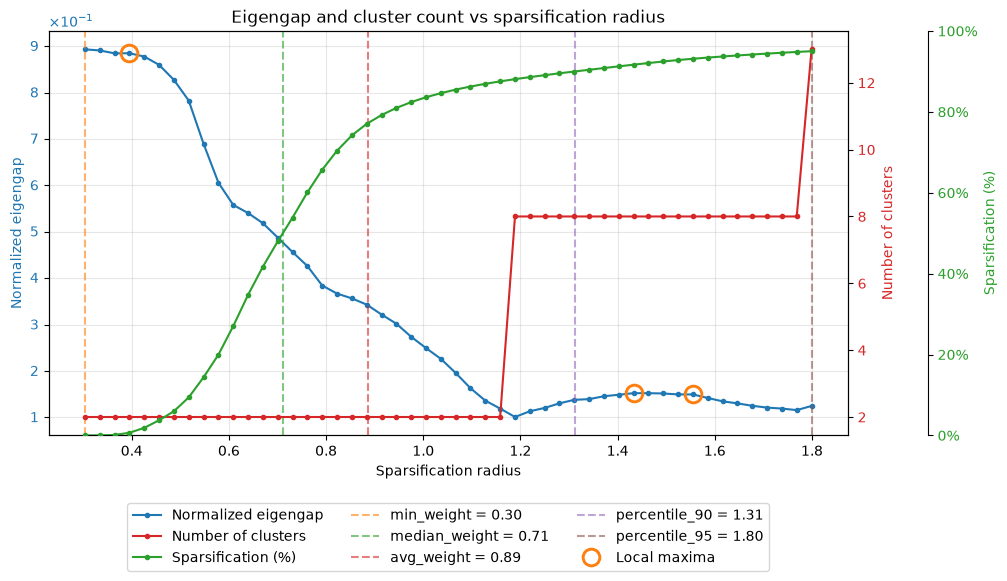

In [ ]:
ax_cluster_vs_sparsity = plot_eigengaps_vs_sparsity(
    result,
    params,
    eigengap_local_maxima_indices=local_maxs_indices,
    output_dir=params.output_dir,
    subfolder="autonomous_local_maxs",
)